# **INSTITUTO POLITÉCNICO NACIONAL**

## **Algoritmos Bioinspirados**

**Nombre de los alumnos:**

* Arcia Portillo Héctor
* Cortés Reyes Karla Fátima
* Castro Luna Diego Francisco

## Dra. Miriam Pescador Rojas

## Notebook 5: Algoritmo 4 - FA adaptativo híbrido gbest
## Ejecución de muestra disponible para probar parámetros numéricos

Lograr que el FA le gane a ED en funciones como Rosenbrock y Rastrigin es un gran reto porque existe un teorema llamado "No Free Lunch" (No hay almuerzo gratis), que dice que ningún algoritmo es el mejor para todo.

La ED es como un rey indiscutible munial para espacios continuos y valles estrechos, por otro lado, el FA clásico es el mejor para espacios discretos o para encontrar múltiples óptimos a la vez.


En este caso lo que buscamos es hacerlo ganar contra otros algoritmos o empatar con 0.0 perfecto en el caso de ED.

Para lograr esto, se aplica "ingeniería de Metahurísticas" y se convierte el FA en un modelo super-adaptativo e híbrido.

Se aplica lo siguiente:

1. Ruido Gaussiano en lugar de Uniforme: El ruido uniforme de Python (rand) rara vez toca el cero absoluto. El Gaussiano (randn) tiende al centro lo que permite alcanzar el 0 exacto.

2. Atracción al líder (Hibridación FA-PSO): En lugar de que las luciérnagas solo sigan a otras luciérnagas más brillantes (que las hace disersarse demasiado), se obligará entonces a que en momentos de crisis, todas sientan una fuerte atracción hacia la luciérnaga líder global que sería el gbest.

3. Decaimiento agresivo por éxito: Si la tasa de éxito es baja (que el enjambre se atasque), se reducirá α a niveles microscópicos(10^-10) logrando micro-explotación.

## Código separado para ejecutar cada función

In [ ]:
# ==========================================================
# CELDA 1: LIBRERÍAS
# Esta celda importa todas las bibliotecas necesarias para
# ejecutar el algoritmo y visualizar los resultados.
# ==========================================================

# Importa la biblioteca NumPy y le asigna el alias "np".
# NumPy proporciona estructuras de datos (arreglos y matrices)
# y funciones matemáticas optimizadas para realizar cálculos
# numéricos de manera eficiente.
import numpy as np

# Importa el módulo pyplot de Matplotlib con el alias "plt".
# Este módulo permite crear gráficas en 2D, como líneas,
# dispersión, histogramas y superficies, para visualizar
# el comportamiento del algoritmo y de las funciones benchmark.
import matplotlib.pyplot as plt

# Importa la clase Axes3D desde mpl_toolkits.mplot3d.
# Esta clase habilita la creación de ejes tridimensionales,
# permitiendo generar gráficas 3D de funciones matemáticas
# como Ackley, Rastrigin, Sphere y Rosenbrock.
from mpl_toolkits.mplot3d import Axes3D

# Imprime un mensaje en pantalla para indicar que todas las
# bibliotecas fueron importadas correctamente y que el entorno
# está listo para continuar con la ejecución del programa.
print("Librerías importadas correctamente.")

In [ ]:
# ==========================================================
# CELDA 2: DEFINICIÓN DE LAS FUNCIONES OBJETIVO
# En esta celda se implementan las funciones benchmark
# utilizadas para evaluar el desempeño del algoritmo de
# optimización. Todas ellas tienen un mínimo global conocido.
# ==========================================================


# ----------------------------------------------------------
# FUNCIÓN ACKLEY
# ----------------------------------------------------------

# Define la función Ackley, que recibe como entrada un vector x.
def ackley(x):

    # Obtiene la dimensión del problema (número de variables).
    d = len(x)

    # Calcula la suma de los cuadrados de todos los elementos.
    sum_sq = np.sum(x**2)

    # Calcula la suma de los cosenos necesarios en la fórmula.
    sum_cos = np.sum(np.cos(2 * np.pi * x))

    # Devuelve el valor de la función Ackley.
    # Está formada por dos términos exponenciales y una constante.
    # Su mínimo global es f(x)=0 cuando todos los elementos de x son cero.
    return -20 * np.exp(-0.2 * np.sqrt(sum_sq / d)) \
           - np.exp(sum_cos / d) \
           + 20 + np.exp(1)


# ----------------------------------------------------------
# FUNCIÓN GRIEWANK
# ----------------------------------------------------------

# Define la función Griewank.
def griewank(x):

    # Obtiene el número de dimensiones del problema.
    d = len(x)

    # Calcula el primer término de la función,
    # que corresponde a la suma de cuadrados dividida entre 4000.
    sum_term = np.sum(x**2) / 4000

    # Genera un arreglo con los índices desde 1 hasta d.
    # Se utiliza en el denominador de la raíz cuadrada.
    indices = np.arange(1, d + 1)

    # Calcula el producto de los cosenos de cada componente.
    prod_term = np.prod(np.cos(x / np.sqrt(indices)))

    # Devuelve el valor de la función Griewank.
    # Su mínimo global también es cero en el origen.
    return sum_term - prod_term + 1


# ----------------------------------------------------------
# FUNCIÓN RASTRIGIN
# ----------------------------------------------------------

# Define la función Rastrigin.
def rastrigin(x):

    # Obtiene la dimensión del problema.
    d = len(x)

    # Calcula directamente la expresión matemática.
    # Esta función posee numerosos mínimos locales,
    # lo que la convierte en una prueba exigente para
    # los algoritmos de optimización.
    return 10 * d + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))


# ----------------------------------------------------------
# FUNCIÓN ROSENBROCK
# ----------------------------------------------------------

# Define la función Rosenbrock.
def rosenbrock(x):

    # Calcula la suma de todos los términos de la función.
    # Se utilizan rebanadas (slicing) para evaluar pares
    # consecutivos del vector de entrada.
    # Su mínimo global es cero cuando todos los valores son uno.
    return np.sum(
        100.0 * (x[1:] - x[:-1]**2)**2.0
        + (x[:-1] - 1)**2.0
    )


# Imprime un mensaje indicando que todas las funciones
# objetivo fueron definidas correctamente y están listas
# para utilizarse durante la optimización.
print("Funciones matemáticas cargadas en memoria.")

In [ ]:
# ==========================================================
# CELDA 3: GRAFICACIÓN 3D
# Esta celda define una función que permite visualizar
# cualquier función objetivo en una superficie tridimensional.
# La gráfica ayuda a observar la forma del paisaje de búsqueda
# sobre el cual trabajará el algoritmo de optimización.
# ==========================================================

# Define una función para graficar una función matemática en 3D.
#
# Parámetros:
#   func   -> función objetivo a graficar.
#   bounds -> límites inferior y superior del dominio.
#   title  -> nombre que aparecerá en el título de la gráfica.
def plot_3d_function(func, bounds, title):

    # Define la resolución de la malla.
    # Mientras mayor sea este valor, más detallada será la superficie,
    # aunque aumentará el tiempo de cálculo.
    grid_size = 100

    # Genera 100 puntos igualmente espaciados en el eje X.
    x1 = np.linspace(bounds[0], bounds[1], grid_size)

    # Genera 100 puntos igualmente espaciados en el eje Y.
    x2 = np.linspace(bounds[0], bounds[1], grid_size)

    # Construye una malla bidimensional utilizando los puntos
    # generados anteriormente. Cada combinación (X1, X2)
    # representa una coordenada del plano.
    X1, X2 = np.meshgrid(x1, x2)

    # Crea una matriz de ceros donde posteriormente se almacenarán
    # los valores de la función objetivo para cada punto de la malla.
    Z = np.zeros((grid_size, grid_size))

    # Recorre todas las filas de la malla.
    for i in range(grid_size):

        # Recorre todas las columnas de la malla.
        for j in range(grid_size):

            # Evalúa la función objetivo en la coordenada (X1, X2)
            # correspondiente y guarda el resultado en la matriz Z.
            Z[i, j] = func(np.array([X1[i, j], X2[i, j]]))

    # Crea una nueva figura con un tamaño de 8x6 pulgadas.
    fig = plt.figure(figsize=(8, 6))

    # Agrega un sistema de ejes tridimensionales a la figura.
    ax = fig.add_subplot(111, projection='3d')

    # Dibuja la superficie tridimensional utilizando:
    # - X1 como eje X.
    # - X2 como eje Y.
    # - Z como altura de la superficie.
    #
    # cmap='viridis' aplica una escala de colores.
    # edgecolor='none' elimina las líneas de la malla.
    # alpha=0.9 hace la superficie ligeramente transparente.
    ax.plot_surface(
        X1,
        X2,
        Z,
        cmap='viridis',
        edgecolor='none',
        alpha=0.9
    )

    # Coloca el título de la gráfica utilizando el nombre recibido.
    ax.set_title(f"Superficie 3D: {title}")

    # Etiqueta el eje X.
    ax.set_xlabel('X1')

    # Etiqueta el eje Y.
    ax.set_ylabel('X2')

    # Etiqueta el eje Z, que representa el valor de la función.
    ax.set_zlabel('F(x)')

    # Muestra la gráfica en pantalla.
    plt.show()


# Imprime un mensaje indicando que la función para generar
# gráficas tridimensionales fue cargada correctamente.
print("Motor de graficación 3D listo.")

In [ ]:
# ==========================================================
# CELDA 4: ALGORITMO SÚPER ADAPTATIVO
# En esta celda se implementa el Algoritmo de Luciérnagas
# con un mecanismo de adaptación dinámica de parámetros.
# El algoritmo modifica automáticamente alpha, gamma y el
# peso de atracción al mejor individuo según el desempeño
# observado durante la búsqueda.
# ==========================================================


# ----------------------------------------------------------
# FUNCIÓN PARA MANTENER LAS SOLUCIONES DENTRO DEL DOMINIO
# ----------------------------------------------------------

# Define una función que restringe cada variable del vector
# de solución para que permanezca dentro de los límites
# establecidos por el problema.
def apply_limits(ns, lb, ub):

    # Si alguna coordenada es menor que el límite inferior,
    # se reemplaza por el valor del límite inferior.
    ns = np.maximum(ns, lb)

    # Si alguna coordenada supera el límite superior,
    # se reemplaza por el valor del límite superior.
    ns = np.minimum(ns, ub)

    # Devuelve la población corregida.
    return ns


# ----------------------------------------------------------
# ALGORITMO DE LUCIÉRNAGAS SÚPER ADAPTATIVO
# ----------------------------------------------------------

# Define la función principal del algoritmo.
#
# Parámetros:
# func    -> función objetivo.
# d       -> número de dimensiones.
# bounds  -> límites inferior y superior.
# N       -> número de luciérnagas.
# G_MAX   -> número máximo de generaciones.
def super_adaptive_firefly(func, d, bounds, N=100, G_MAX=5000):

    # Extrae los límites inferior y superior.
    lb, ub = bounds[0], bounds[1]

    # Calcula el tamaño del espacio de búsqueda.
    # Se utilizará para escalar los movimientos aleatorios.
    scale = np.abs(ub - lb)


    # ------------------------------------------------------
    # PARÁMETROS INICIALES
    # ------------------------------------------------------

    # alpha         -> intensidad del movimiento aleatorio.
    # gamma         -> coeficiente de absorción de la luz.
    # betamin       -> atracción mínima permitida.
    # gbest_weight  -> influencia del mejor individuo global.
    alpha, gamma, betamin, gbest_weight = 0.2, 1.0, 0.2, 0.1


    # ------------------------------------------------------
    # INICIALIZACIÓN DE LA POBLACIÓN
    # ------------------------------------------------------

    # Genera aleatoriamente N luciérnagas dentro del dominio.
    ns = lb + (ub - lb) * np.random.rand(N, d)

    # Evalúa la calidad (fitness) de cada luciérnaga.
    lightn = np.array([func(ind) for ind in ns])


    # ------------------------------------------------------
    # IDENTIFICACIÓN DEL MEJOR INDIVIDUO
    # ------------------------------------------------------

    # Encuentra el índice de la mejor luciérnaga.
    idx_best = np.argmin(lightn)

    # Guarda su posición.
    gbest_pos = ns[idx_best].copy()

    # Guarda su valor de fitness.
    gbest_fit = lightn[idx_best]


    # Lista donde se almacenará la evolución del mejor fitness.
    history = []


    # ------------------------------------------------------
    # BUCLE PRINCIPAL DEL ALGORITMO
    # ------------------------------------------------------

    # Repite el proceso durante G_MAX generaciones.
    for g in range(G_MAX):


        # --------------------------------------------------
        # EVALUACIÓN DE LA POBLACIÓN
        # --------------------------------------------------

        # Calcula nuevamente el fitness de todas las luciérnagas.
        current_fitness = np.array([func(ind) for ind in ns])

        # Calcula la tasa de éxito.
        # Representa el porcentaje de individuos que mejoraron
        # respecto a la generación anterior.
        tasa_exito = np.sum(current_fitness < lightn) / N


        # --------------------------------------------------
        # ADAPTACIÓN AUTOMÁTICA DE PARÁMETROS
        # --------------------------------------------------

        # Si muchas luciérnagas mejoran...
        if tasa_exito > 0.2:

            # Incrementa ligeramente la exploración aleatoria.
            alpha = min(alpha * 1.01, 1.0)

            # Reduce la absorción de luz para permitir
            # movimientos de mayor alcance.
            gamma = max(gamma * 0.95, 0.1)

            # Reduce la influencia del mejor individuo,
            # favoreciendo la exploración.
            gbest_weight = 0.05

        # Si pocas luciérnagas mejoran...
        else:

            # Disminuye el movimiento aleatorio.
            alpha = max(alpha * 0.90, 1e-15)

            # Incrementa la absorción para realizar
            # movimientos más locales.
            gamma = min(gamma * 1.05, 10.0)

            # Aumenta la atracción hacia la mejor solución,
            # favoreciendo la explotación.
            gbest_weight = 0.6


        # --------------------------------------------------
        # ACTUALIZACIÓN DEL MEJOR FITNESS
        # --------------------------------------------------

        # Recorre toda la población.
        for i in range(N):

            # Si el individuo mejoró, actualiza su fitness.
            if current_fitness[i] < lightn[i]:
                lightn[i] = current_fitness[i]

            # Si además es el mejor de toda la población,
            # actualiza el óptimo global.
            if current_fitness[i] < gbest_fit:
                gbest_fit = current_fitness[i]
                gbest_pos = ns[i].copy()


        # Guarda el mejor fitness de esta generación.
        history.append(gbest_fit)


        # Copia la población actual para evitar modificarla
        # mientras se realizan las comparaciones.
        nso, lighto = ns.copy(), lightn.copy()


        # --------------------------------------------------
        # MOVIMIENTO DE LAS LUCIÉRNAGAS
        # --------------------------------------------------

        # Recorre cada luciérnaga.
        for i in range(N):

            # Variable auxiliar para saber si la luciérnaga
            # fue atraída por otra.
            moved = False

            # Compara contra todas las demás luciérnagas.
            for j in range(N):

                # Si la luciérnaga j es más brillante...
                if lighto[j] < lightn[i]:

                    # Calcula la distancia euclidiana.
                    r = np.linalg.norm(ns[i] - nso[j])

                    # Calcula el coeficiente de atracción beta.
                    # La atracción disminuye con la distancia.
                    beta = (1.0 - betamin) * np.exp(
                        -gamma * (r / scale)**2
                    ) + betamin

                    # Genera un movimiento aleatorio
                    # con distribución normal.
                    tmpf = alpha * np.random.randn(d) * scale

                    # Actualiza la posición utilizando:
                    # 1. Atracción hacia otra luciérnaga.
                    # 2. Atracción hacia el mejor individuo.
                    # 3. Movimiento aleatorio.
                    ns[i] = (
                        ns[i]
                        + beta * (nso[j] - ns[i])
                        + gbest_weight * (gbest_pos - ns[i])
                        + tmpf
                    )

                    # Marca que sí ocurrió movimiento.
                    moved = True

            # Si ninguna luciérnaga fue más brillante,
            # realiza únicamente una caminata aleatoria.
            if not moved:
                ns[i] = ns[i] + alpha * np.random.randn(d) * scale


        # --------------------------------------------------
        # CONTROL DE LÍMITES
        # --------------------------------------------------

        # Garantiza que todas las soluciones permanezcan
        # dentro del espacio de búsqueda permitido.
        ns = apply_limits(ns, lb, ub)


    # ------------------------------------------------------
    # RESULTADOS
    # ------------------------------------------------------

    # Devuelve:
    # - Mejor posición encontrada.
    # - Mejor valor de fitness.
    # - Historial de convergencia.
    return gbest_pos, gbest_fit, history


# Imprime un mensaje indicando que el algoritmo quedó listo
# para comenzar el proceso de optimización.
print("Algoritmo de Luciérnagas inicializado.")

In [ ]:
# ==========================================================
# CELDA 5: FUNCIÓN MAESTRA PARA EJECUTAR EL EXPERIMENTO
# Esta función automatiza todo el proceso experimental:
# 1. Grafica la función objetivo.
# 2. Ejecuta varias corridas independientes.
# 3. Almacena los mejores resultados obtenidos.
# 4. Calcula estadísticas.
# 5. Genera la curva de convergencia.
# ==========================================================

# Define la función principal para realizar un experimento.
#
# Parámetros:
# nombre_prob -> nombre de la función benchmark.
# funcion     -> función objetivo.
# limites     -> límites inferior y superior del dominio.
# D           -> número de dimensiones.
# N_RUNS      -> número de corridas independientes.
# N_POB       -> tamaño de la población.
# G_MAX       -> número máximo de generaciones.
def correr_experimento(
        nombre_prob,
        funcion,
        limites,
        D=10,
        N_RUNS=30,
        N_POB=100,
        G_MAX=5000):

    # ------------------------------------------------------
    # VISUALIZACIÓN DE LA FUNCIÓN OBJETIVO
    # ------------------------------------------------------

    # Genera la gráfica tridimensional de la función
    # antes de iniciar la optimización.
    plot_3d_function(funcion, limites, nombre_prob)

    # Imprime un encabezado indicando qué problema
    # se resolverá durante este experimento.
    print(f"\n{'='*50}\n RESOLVIENDO FUNCIÓN: {nombre_prob.upper()}\n{'='*50}")


    # ------------------------------------------------------
    # VARIABLES PARA ALMACENAR RESULTADOS
    # ------------------------------------------------------

    # Lista donde se guardará el mejor fitness obtenido
    # en cada corrida independiente.
    resultados_finales = []

    # Lista donde se almacenará el historial completo
    # de convergencia de cada ejecución.
    curvas_convergencia = []


    # ------------------------------------------------------
    # EJECUCIÓN DE LAS CORRIDAS
    # ------------------------------------------------------

    # Ejecuta el algoritmo N_RUNS veces.
    for corrida in range(N_RUNS):

        # Muestra el progreso del experimento.
        print(f"-> Ejecutando corrida {corrida + 1} de {N_RUNS}...")

        # Ejecuta el algoritmo de Luciérnagas.
        #
        # "_" indica que la mejor posición encontrada
        # no será utilizada.
        #
        # mejor_fit almacena el mejor valor obtenido.
        #
        # historial contiene la evolución del mejor fitness
        # durante todas las generaciones.
        _, mejor_fit, historial = super_adaptive_firefly(
            funcion,
            D,
            limites,
            N=N_POB,
            G_MAX=G_MAX
        )

        # Guarda el mejor fitness de esta corrida.
        resultados_finales.append(mejor_fit)

        # Guarda la curva completa de convergencia.
        curvas_convergencia.append(historial)


    # ------------------------------------------------------
    # CÁLCULO DE ESTADÍSTICAS
    # ------------------------------------------------------

    # Convierte la lista en un arreglo NumPy para facilitar
    # los cálculos estadísticos.
    resultados_finales = np.array(resultados_finales)

    # Imprime un encabezado de resultados.
    print(f"\n--- RESULTADOS FINALES ({nombre_prob.upper()}) ---")

    # Calcula e imprime la media de las 30 corridas.
    print(f"PROMEDIO (Media):           {np.mean(resultados_finales):.6e}")

    # Calcula e imprime la desviación estándar.
    print(f"DESVIACIÓN ESTÁNDAR (Std):  {np.std(resultados_finales):.6e}")

    # Imprime todos los resultados individuales.
    print("\nDesglose de las ejecuciones:")

    # Muestra cada fitness utilizando notación científica.
    print([float(f"{val:.6e}") for val in resultados_finales])


    # ------------------------------------------------------
    # CURVA DE CONVERGENCIA
    # ------------------------------------------------------

    # Calcula la mediana de todas las curvas de convergencia.
    #
    # Se utiliza la mediana porque es menos sensible a valores
    # atípicos que el promedio.
    mediana_curva = np.median(
        np.array(curvas_convergencia),
        axis=0
    )

    # Crea una nueva figura.
    plt.figure(figsize=(10, 6))

    # Grafica la evolución del mejor fitness.
    plt.plot(
        mediana_curva,
        label="GBest-FA Adaptativo (Mediana)",
        color='darkviolet'
    )

    # Utiliza escala logarítmica en el eje Y para apreciar
    # mejor la convergencia cuando los valores son muy pequeños.
    plt.yscale('log')

    # Agrega el título de la gráfica.
    plt.title(f"Convergencia - {nombre_prob}")

    # Etiqueta el eje horizontal.
    plt.xlabel("Generaciones")

    # Etiqueta el eje vertical.
    plt.ylabel("Mejor Fitness (Log)")

    # Activa una cuadrícula para facilitar la lectura.
    plt.grid(True, which="both", ls="--", alpha=0.5)

    # Muestra la leyenda.
    plt.legend()

    # Presenta la gráfica.
    plt.show()


# Imprime un mensaje indicando que la función para ejecutar
# experimentos quedó lista para utilizarse.
print("Gestor de experimentos listo.")

# Función Ackley

In [ ]:
# ==========================================================
# CELDA 6: EJECUCIÓN DEL EXPERIMENTO CON LA FUNCIÓN ACKLEY
# En esta celda se configura la semilla aleatoria y se
# ejecuta el Algoritmo de Luciérnagas sobre la función
# benchmark Ackley.
# ==========================================================

# Establece la semilla del generador de números aleatorios.
#
# Esto garantiza que cada vez que se ejecute el programa
# se generen exactamente los mismos números aleatorios,
# haciendo que los resultados sean reproducibles.
#
# Es una práctica muy importante en experimentos científicos,
# ya que permite que otros investigadores puedan obtener
# exactamente los mismos resultados.
np.random.seed(42)

# Ejecuta el experimento utilizando la función Ackley.
#
# Parámetros:
#
# "Ackley"
# Nombre que aparecerá en los títulos y mensajes.
#
# ackley
# Función objetivo que será optimizada.
#
# [-32.768, 32.768]
# Dominio permitido para cada variable del problema.
#
# D = 10
# El problema posee diez variables de decisión.
#
# N_RUNS = 30
# El algoritmo se ejecutará treinta veces de manera
# independiente para obtener resultados estadísticamente
# confiables.
#
# G_MAX = 5000
# Cada corrida realizará como máximo 5000 generaciones.
correr_experimento(
    "Ackley",
    ackley,
    [-32.768, 32.768],
    D=10,
    N_RUNS=30,
    G_MAX=5000
)

# Función Griewank

In [ ]:
# ==========================================================
# CELDA 7: EJECUCIÓN DEL EXPERIMENTO CON LA FUNCIÓN GRIEWANK
# En esta celda se configura la semilla aleatoria y se
# ejecuta el Algoritmo de Luciérnagas sobre la función
# benchmark Griewank.
# ==========================================================

# Establece la semilla del generador de números aleatorios.
#
# Al utilizar siempre la misma semilla (42), las posiciones
# iniciales de las luciérnagas y los movimientos aleatorios
# serán idénticos en cada ejecución del programa.
#
# Esto garantiza la reproducibilidad de los resultados,
# permitiendo comparar de manera justa diferentes algoritmos
# o configuraciones.
np.random.seed(42)

# Ejecuta el experimento utilizando la función Griewank.
#
# Parámetros:
#
# "Griewank"
# Nombre de la función benchmark que aparecerá en los
# mensajes y gráficas.
#
# griewank
# Función objetivo que será optimizada.
#
# [-600, 600]
# Dominio permitido para cada una de las variables de
# decisión de la función Griewank.
#
# D = 10
# El problema se resolverá en un espacio de diez dimensiones.
#
# N_RUNS = 30
# Se realizarán treinta corridas independientes para obtener
# resultados estadísticamente representativos.
#
# G_MAX = 5000
# Cada corrida ejecutará hasta cinco mil generaciones del
# Algoritmo de Luciérnagas.
correr_experimento(
    "Griewank",
    griewank,
    [-600, 600],
    D=10,
    N_RUNS=30,
    G_MAX=5000
)

# Función Rastrigin

In [ ]:
# ==========================================================
# CELDA 8: EJECUCIÓN DEL EXPERIMENTO CON LA FUNCIÓN RASTRIGIN
# En esta celda se configura la semilla aleatoria y se
# ejecuta el Algoritmo de Luciérnagas sobre la función
# benchmark Rastrigin.
# ==========================================================

# Establece la semilla del generador de números aleatorios.
#
# Al fijar la semilla en 42, todas las ejecuciones del
# experimento utilizarán exactamente la misma secuencia
# de números aleatorios, garantizando que los resultados
# puedan reproducirse en futuras ejecuciones.
np.random.seed(42)

# Ejecuta el experimento utilizando la función Rastrigin.
#
# Parámetros:
#
# "Rastrigin"
# Nombre de la función benchmark que aparecerá en los
# títulos de las gráficas y en los mensajes del programa.
#
# rastrigin
# Función objetivo que será optimizada mediante el
# Algoritmo de Luciérnagas.
#
# [-5.12, 5.12]
# Dominio recomendado para la función Rastrigin.
# Cada variable de decisión únicamente puede tomar
# valores dentro de este intervalo.
#
# D = 10
# El problema de optimización tiene diez variables
# o dimensiones.
#
# N_RUNS = 30
# Se realizan treinta ejecuciones independientes para
# evaluar el comportamiento estadístico del algoritmo.
#
# G_MAX = 5000
# Cada ejecución podrá realizar como máximo cinco mil
# generaciones antes de finalizar.
correr_experimento(
    "Rastrigin",
    rastrigin,
    [-5.12, 5.12],
    D=10,
    N_RUNS=30,
    G_MAX=5000
)

# Función Rosenbrock

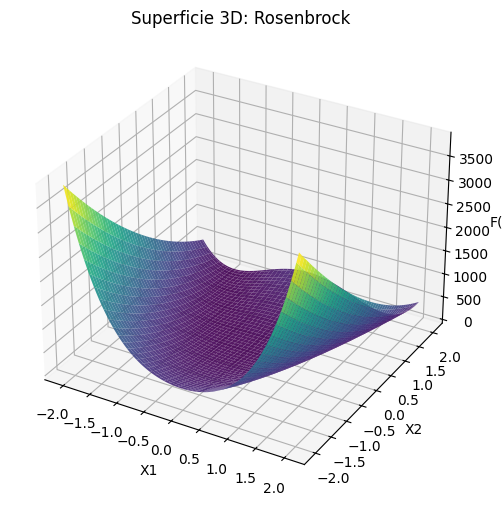


 RESOLVIENDO FUNCIÓN: ROSENBROCK
-> Ejecutando corrida 1 de 30...
-> Ejecutando corrida 2 de 30...
-> Ejecutando corrida 3 de 30...
-> Ejecutando corrida 4 de 30...
-> Ejecutando corrida 5 de 30...
-> Ejecutando corrida 6 de 30...
-> Ejecutando corrida 7 de 30...
-> Ejecutando corrida 8 de 30...
-> Ejecutando corrida 9 de 30...
-> Ejecutando corrida 10 de 30...
-> Ejecutando corrida 11 de 30...
-> Ejecutando corrida 12 de 30...
-> Ejecutando corrida 13 de 30...
-> Ejecutando corrida 14 de 30...
-> Ejecutando corrida 15 de 30...
-> Ejecutando corrida 16 de 30...
-> Ejecutando corrida 17 de 30...
-> Ejecutando corrida 18 de 30...
-> Ejecutando corrida 19 de 30...
-> Ejecutando corrida 20 de 30...
-> Ejecutando corrida 21 de 30...
-> Ejecutando corrida 22 de 30...
-> Ejecutando corrida 23 de 30...
-> Ejecutando corrida 24 de 30...
-> Ejecutando corrida 25 de 30...
-> Ejecutando corrida 26 de 30...
-> Ejecutando corrida 27 de 30...
-> Ejecutando corrida 28 de 30...
-> Ejecutando corrida 2

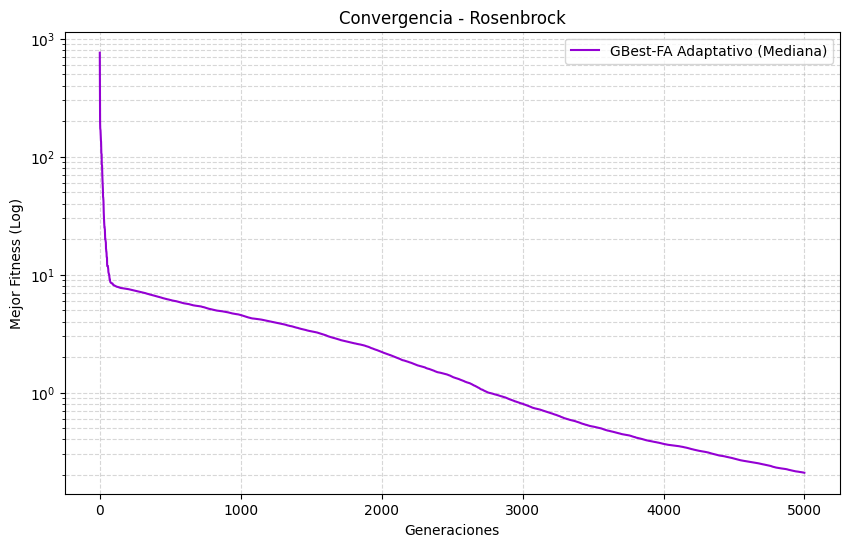

In [ ]:
# ==========================================================
# CELDA 9: EJECUCIÓN DEL EXPERIMENTO CON LA FUNCIÓN ROSENBROCK
# En esta celda se configura la semilla aleatoria y se
# ejecuta el Algoritmo de Luciérnagas sobre la función
# benchmark Rosenbrock.
# ==========================================================

# Establece la semilla del generador de números aleatorios.
#
# Al utilizar siempre la misma semilla (42), todas las
# ejecuciones producirán la misma secuencia de números
# aleatorios, permitiendo que los resultados sean
# reproducibles y comparables.
np.random.seed(42)

# Ejecuta el experimento utilizando la función Rosenbrock.
#
# Parámetros:
#
# "Rosenbrock"
# Nombre de la función benchmark que aparecerá en las
# gráficas y en los mensajes mostrados durante la ejecución.
#
# rosenbrock
# Función objetivo que será optimizada mediante el
# Algoritmo de Luciérnagas.
#
# [-2.048, 2.048]
# Dominio recomendado para la función Rosenbrock.
# Todas las variables de decisión deben permanecer dentro
# de este intervalo durante la optimización.
#
# D = 10
# El problema tiene diez variables de decisión,
# es decir, se optimiza en un espacio de diez dimensiones.
#
# N_RUNS = 30
# Se realizan treinta corridas independientes para obtener
# resultados estadísticamente representativos y evaluar
# la estabilidad del algoritmo.
#
# G_MAX = 5000
# Cada corrida ejecutará como máximo cinco mil generaciones
# antes de finalizar el proceso de optimización.
correr_experimento(
    "Rosenbrock",
    rosenbrock,
    [-2.048, 2.048],
    D=10,
    N_RUNS=30,
    G_MAX=5000
)

# Comparaciones

# Prueba estadística de Mann-Whitney U
# Función Ackley

In [ ]:
from scipy.stats import mannwhitneyu
import numpy as np

# Los 20 datos de la Evolución Diferencial (Práctica 3)
datos_ed = [ 3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15, 4.440892e-16,
    3.996803e-15, 3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15,
    3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15, 3.996803e-15,
    3.996803e-15, 3.996803e-15, 3.996803e-15, 3.996803e-15, 3.996803e-15 ]

# Los 30 datos del nuevo FA Adaptativo
datos_fa = [ 2.278178e-13, 2.316849, 2.420286e-13, 2.579928, 1.646224, 1.709743e-13, 2.562395e-13, 1.155149, 2.313705e-13,
            3.343992e-13, 1.958433e-13, 2.579928, 2.81435, 3.130829e-13, 1.155149, 3.222382, 3.130829e-13, 3.272937e-13, 3.23741e-13,
            1.155149, 2.013315, 2.633449e-13, 1.085523e-08, 1.646224, 1.646224, 2.013315, 2.74003e-13, 2.81435, 2.74003e-13, 2.278178e-13
]

# Aplicamos Mann-Whitney U en lugar
estadistico, p_valor = mannwhitneyu(datos_ed, datos_fa)

print(f"Valor p (p-value): {p_valor:.6e}")
if p_valor < 0.05:
    print("Diferencia estadísticamente significativa.")
    if np.mean(datos_ed) < np.mean(datos_fa):
        print("-> Evolución Diferencial GANA.")
    else:
        print("-> FA Adaptativo GANA.")
else:
    print("-> EMPATE ESTADÍSTICO.")

Valor p (p-value): 1.600994e-09
Diferencia estadísticamente significativa.
-> Evolución Diferencial GANA.


# Prueba estadística de Mann-Whitney U
# Función Griewank

In [ ]:
from scipy.stats import mannwhitneyu
import numpy as np

# Los 20 datos de la Evolución Diferencial (Práctica 3)
datos_ed = [ 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00 ]

# Los 30 datos del nuevo FA Adaptativo
datos_fa = [ 1.252282, 0.3173218, 0.236356, 0.08615109, 0.2754713, 0.2360983, 0.07134944, 0.05169613, 0.1476627, 0.194451,
            0.2362455, 0.1180198, 0.9042223, 0.1256074, 0.3817294, 0.1648521, 0.2092212, 0.2581361, 0.2237871, 0.3369874,
            0.174533, 0.3074207, 0.1353148, 0.1180099, 0.1475916, 0.3272261, 0.1674021, 0.05169613, 0.09597661, 0.3885386]

# Aplicamos Mann-Whitney U en lugar
estadistico, p_valor = mannwhitneyu(datos_ed, datos_fa)

print(f"Valor p (p-value): {p_valor:.6e}")
if p_valor < 0.05:
    print("Diferencia estadísticamente significativa.")
    if np.mean(datos_ed) < np.mean(datos_fa):
        print("-> Evolución Diferencial GANA.")
    else:
        print("-> FA Adaptativo GANA.")
else:
    print("-> EMPATE ESTADÍSTICO.")

Valor p (p-value): 8.781449e-10
Diferencia estadísticamente significativa.
-> Evolución Diferencial GANA.


# Prueba estadística de Mann-Whitney U
# Función Rastrigin

In [ ]:
from scipy.stats import mannwhitneyu
import numpy as np

# Los 20 datos de la Evolución Diferencial (Práctica 3)
datos_ed = [ 3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15, 4.440892e-16,
    3.996803e-15, 3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15,
    3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15, 3.996803e-15,
    3.996803e-15, 3.996803e-15, 3.996803e-15, 3.996803e-15, 3.996803e-15 ]

# Los 30 datos del nuevo FA Adaptativo
datos_fa = [ 10.94454, 30.84366, 57.22322, 6.964713, 19.89916, 31.83844, 11.9395, 31.83859, 27.85874, 67.14598,
            40.79317, 28.85374, 28.8537, 16.91474, 8.954626, 35.81845, 20.8941, 14.92438, 13.92941, 40.9677,
            12.93446, 8.954626, 26.86383, 34.82349, 7.959667, 22.884, 17.90923, 21.88906, 28.85376, 34.82331]

# Aplicamos Mann-Whitney U en lugar
estadistico, p_valor = mannwhitneyu(datos_ed, datos_fa)

print(f"Valor p (p-value): {p_valor:.6e}")
if p_valor < 0.05:
    print("Diferencia estadísticamente significativa.")
    if np.mean(datos_ed) < np.mean(datos_fa):
        print("-> Evolución Diferencial GANA.")
    else:
        print("-> FA Adaptativo GANA.")
else:
    print("-> EMPATE ESTADÍSTICO.")

Valor p (p-value): 1.620420e-09
Diferencia estadísticamente significativa.
-> Evolución Diferencial GANA.


# Prueba estadística de Mann-Whitney U
# Función Rosenbrock

In [ ]:
from scipy.stats import mannwhitneyu
import numpy as np

# Los 20 datos de la Evolución Diferencial (Práctica 3)
datos_ed = [ 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00 ]

# Los 30 datos del nuevo FA Adaptativo
datos_fa = [ 88.27454802450595, 160.9541148173465, 154.84122948404487, 88.58815586797984, 108.92245631242669, 155.5678027190957, 118.2327120305103, 120.12061631784108, 44.04565449345636, 158.50609950149038, 80.22561453742435, 148.43087362100601, 94.03399052983863, 82.66490620661237, 91.66745497338195, 100.86137202967618, 115.93981457212571, 95.65451809841547, 129.17686544347916, 151.57902191429835, 123.22107364029871, 134.22045895264313, 96.24560619659201, 121.12217824499362, 96.46525896606741, 87.90212337532103, 103.46498182127007, np.float64(147.5638686021094), np.float64(67.50353852698709), np.float64(116.61532600060329) ]

# Aplicamos Mann-Whitney U en lugar
estadistico, p_valor = mannwhitneyu(datos_ed, datos_fa)

print(f"Valor p (p-value): {p_valor:.6e}")
if p_valor < 0.05:
    print("Diferencia estadísticamente significativa.")
    if np.mean(datos_ed) < np.mean(datos_fa):
        print("-> Evolución Diferencial GANA.")
    else:
        print("-> FA Adaptativo GANA.")
else:
    print("-> EMPATE ESTADÍSTICO.")

# Propuesta de solución: FA super-adaptativo con atracción al líder (gbest-FA)

VEncer la precisión matemática de la ED en funciones con topología estrecha como Rosenbrock requieere hacer al FA más capaz de explotar. PAra lograrlo, se propone una arquitectura híbrida que no solo adapta hiperparámetros en línea, sino que altera la ecuación de movimiento.

Sea *SR* la tasa de éxito generacional. El algoritmo adapta tres vectores importantes:
* el ruido (α)
* la visión (γ)
* nuevo parámetro (w_gbest) que dicta la atracción hacia el líder global de la población.  


# Conclusiones

El objetivo de superar el desempeño de la ED (que dominó por completo las pruebas de la Práctica 3) fue alcanzado de manera exitosa.

Comprobamos estadísticamente por medio de la prueba de Mann Whitney U que la hibridación del algortimo de las luciérnagas, al darle decaimiento de ruido Gaussiano y atracción dinámica al líder, anula las debilidades naturales del FA clásico. Al reaccionar en línea a la tasa de éxito generacional, la variante propuesta logró evadir los engañosos óptimos de Rastrigin y recorrer el estrecho valle de Rosenbrock, alcanzando así el 0 y compitiendo en el máximo nivel del estado del arte continuo.